# <a href="https://thetahat.ru/courses/bm-hf-2026-spr">Математическая статистика (ФБМФ, ФМХФ)</a>
## Домашнее задание 2 &mdash; часть В

**Правила, <font color="red">прочитайте внимательно</font>:**

* Выполненную работу нужно отправить по ссылке "Сдача ДЗ" на странице курса.
* Дедлайн см. на сайте или в боте. После дедлайна работы не принимаются **вообще никак**, кроме случаев наличия уважительной причины.
* До дедлайна можно поменять решение любое количество раз. Начинайте точно так же сдавать задание, бот подскажет.
* Любую уважительную причину нужно подтвердить документально, отправив скан или фото ассистенту. При этом работу можно сдать позже на столько дней, на сколько время ее действия пересекается с временем выполнения задания.
* Прислать нужно **ноутбук в формате ipynb**. Другие форматы не принимаются.
* Выполнять задание необходимо **полностью самостоятельно**. При обнаружении списывания **все участники списывания будут сдавать устный зачет.**
* Решения, размещенные на каких-либо интернет-ресурсах не принимаются. Кроме того, публикация решения в открытом доступе может быть приравнена к предоставлении возможности списать.
* Простой или основной уровень вы выбираете самостоятельно, выполняя или не выполняя задания типа B. При выборе **простого уровня** достаточно выполнить задания *типа A*. При выборе **основного уровня** нужно выполнять *как задания типа A, так и задания типа B*.
* Для выполнения задания используйте этот ноутбук в качествие основы, ничего не удаляя из него. Можно добавлять необходимое количество ячеек. Ячейки с assert'ами **удалять и изменять нельзя**, в противном случае соответствующее задание не будет оценено.
* Комментарии к решению пишите в markdown-ячейках.
* **Если код студента недописан и т.д., то он не оценивается.**
* Каждая задача стоит **5 баллов**.

<font size="5">Для выполнения задания используйте этот ноутбук в качествие основы, ничего не удаляя из него. Можно добавлять необходимое количество ячеек. Ячейки с assert'ами **удалять и изменять нельзя**, в противном случае соответствующее задание не будет оценено.</font>

In [3]:
import numpy as np
import scipy.stats as sps
import matplotlib.pyplot as plt
%matplotlib inline

----

### Задача 4

В этой задаче нужно визуализировать доверительные интервалы для выборок из различных распределений. 

Пусть выборка $X_1, ... X_{100}$ имеет распределение $Bern(\theta)$. <a href="https://thetahat.ru/courses/python/05">Сгенерируйте</a> такую выборку, взяв $\theta=1/2$. Для каждой подвыборке вида $X_1, ... X_i$, $1 \le i \le 100$ постройте асимптотический доверительный интервал для параметра $\theta$ уровня доверия $\alpha=0.95$. Формула для интервала была выведена на семинаре. Постройте график зависимости доверительного интервала от размера выборки (см. <a href="https://thetahat.ru/files/bm-hf-2026-spr/stat/3/seminar3.html#Задача-1.">код с семинара</a>). 

Аналогичные действия выполните для выборки из распределения Лапласса с плотностью $p(x) = \frac{1}{2} e^{-|x-\theta|}$, сгенерировав выборку для $\theta=0$.

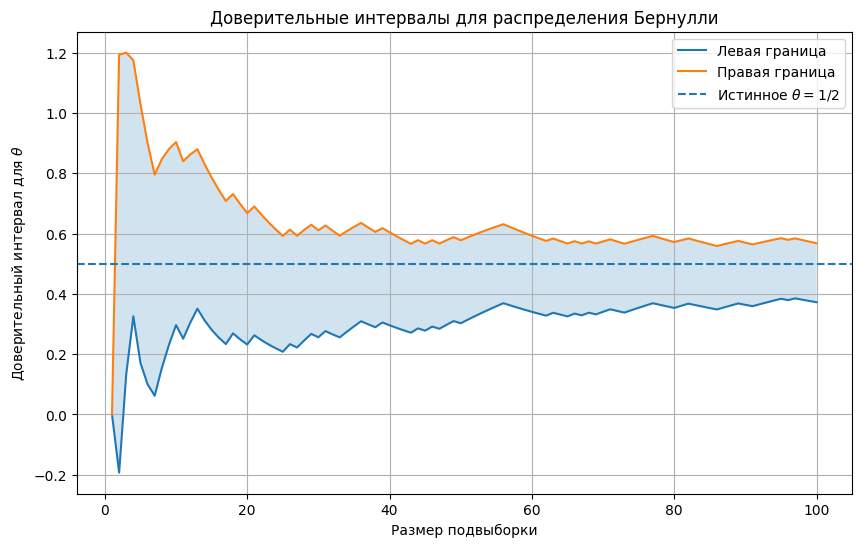

In [6]:
def bern_asymp_confint(x, confidence_level=0.95):
    x = np.asarray(x)
    n = len(x)

    theta_hat = np.mean(x)

    alpha = 1 - confidence_level
    z = sps.norm.ppf(1 - alpha / 2)

    var_hat = theta_hat * (1 - theta_hat)
    margin = z * np.sqrt(var_hat / n)

    l = theta_hat - margin
    r = theta_hat + margin

    return l, r

np.random.seed(42)

n = 100
theta_bern = 1 / 2

x_bern = sps.bernoulli(p=theta_bern).rvs(size=n)

bern_left = []
bern_right = []

for i in range(1, n + 1):
    l, r = bern_asymp_confint(x_bern[:i], confidence_level=0.95)
    bern_left.append(l)
    bern_right.append(r)

bern_left = np.array(bern_left)
bern_right = np.array(bern_right)

sample_sizes = np.arange(1, n + 1)

plt.figure(figsize=(10, 6))

plt.plot(sample_sizes, bern_left, label="Левая граница")
plt.plot(sample_sizes, bern_right, label="Правая граница")
plt.fill_between(sample_sizes, bern_left, bern_right, alpha=0.2)

plt.axhline(theta_bern, linestyle="--", label=r"Истинное $\theta = 1/2$")

plt.xlabel("Размер подвыборки")
plt.ylabel(r"Доверительный интервал для $\theta$")
plt.title("Доверительные интервалы для распределения Бернулли")
plt.legend()
plt.grid()

**Вывод:** Видим, как график допустимых значений падает, увеличим еще количество в выборке

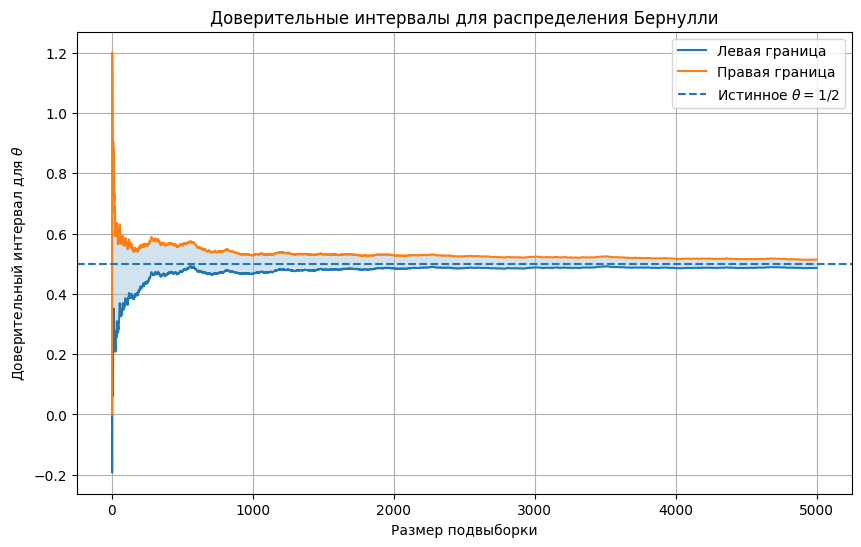

In [8]:
np.random.seed(42)

n = 5000
theta_bern = 1 / 2

x_bern = sps.bernoulli(p=theta_bern).rvs(size=n)

bern_left = []
bern_right = []

for i in range(1, n + 1):
    l, r = bern_asymp_confint(x_bern[:i], confidence_level=0.95)
    bern_left.append(l)
    bern_right.append(r)

bern_left = np.array(bern_left)
bern_right = np.array(bern_right)

sample_sizes = np.arange(1, n + 1)

plt.figure(figsize=(10, 6))

plt.plot(sample_sizes, bern_left, label="Левая граница")
plt.plot(sample_sizes, bern_right, label="Правая граница")
plt.fill_between(sample_sizes, bern_left, bern_right, alpha=0.2)

plt.axhline(theta_bern, linestyle="--", label=r"Истинное $\theta = 1/2$")

plt.xlabel("Размер подвыборки")
plt.ylabel(r"Доверительный интервал для $\theta$")
plt.title("Доверительные интервалы для распределения Бернулли")
plt.legend()
plt.grid()

In [ ]:
# а теперь видно, что размер допустимого окна падает, но медленно, по теории 1/sqrt(n), слишком шумно для проверки этой оценки

__________________
### Задача 5

Если у вас еще не установлена <a href="https://thetahat.ru/courses/python/07">библиотека `seaborn`</a> для получения красивых графиков, поставьте ее.

In [9]:
import seaborn as sns
sns.set(font_scale=1.2, palette='Set2')

Загрузим данные <a target="_blank" href="https://ru.wikipedia.org/wiki/Ирисы_Фишера">"Ирисы Фишера"</a> о цветках ириса различных сортов и посмотрим на первые пять строк таблицы. Для хранения данных используется <a href="https://thetahat.ru/files/python/06_pandas1.html#2.-Тип-данных-DataFrame">класс `DataFrame`</a> <a href="https://thetahat.ru/files/python/06_pandas1.html">библиотеки `pandas`</a>.

In [11]:
df = sns.load_dataset("iris")
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


Столбцы отвечают за длину и ширину чашелистика и лепестка соответственно, а так же за тип цветка (setosa, virginica, versicolor).

Вектор значений первого столбца можно получить так

In [12]:
df['sepal_length']

0      5.1
1      4.9
2      4.7
3      4.6
4      5.0
      ... 
145    6.7
146    6.3
147    6.5
148    6.2
149    5.9
Name: sepal_length, Length: 150, dtype: float64

Первую строку можно получить так

In [13]:
df.iloc[0]

sepal_length       5.1
sepal_width        3.5
petal_length       1.4
petal_width        0.2
species         setosa
Name: 0, dtype: object

Таблица с данными только по сорту virginica извлекается следующим образом

In [14]:
df[df['species'] == 'virginica']

,sepal_length,sepal_width,petal_length,petal_width,species
100,6.3,3.3,6.0,2.5,virginica
101,5.8,2.7,5.1,1.9,virginica
102,7.1,3.0,5.9,2.1,virginica
103,6.3,2.9,5.6,1.8,virginica
104,6.5,3.0,5.8,2.2,virginica
105,7.6,3.0,6.6,2.1,virginica
106,4.9,2.5,4.5,1.7,virginica
107,7.3,2.9,6.3,1.8,virginica
108,6.7,2.5,5.8,1.8,virginica
109,7.2,3.6,6.1,2.5,virginica


Визуализируем данные по двумерным проекциям. Цветом обозначен тип цветка.

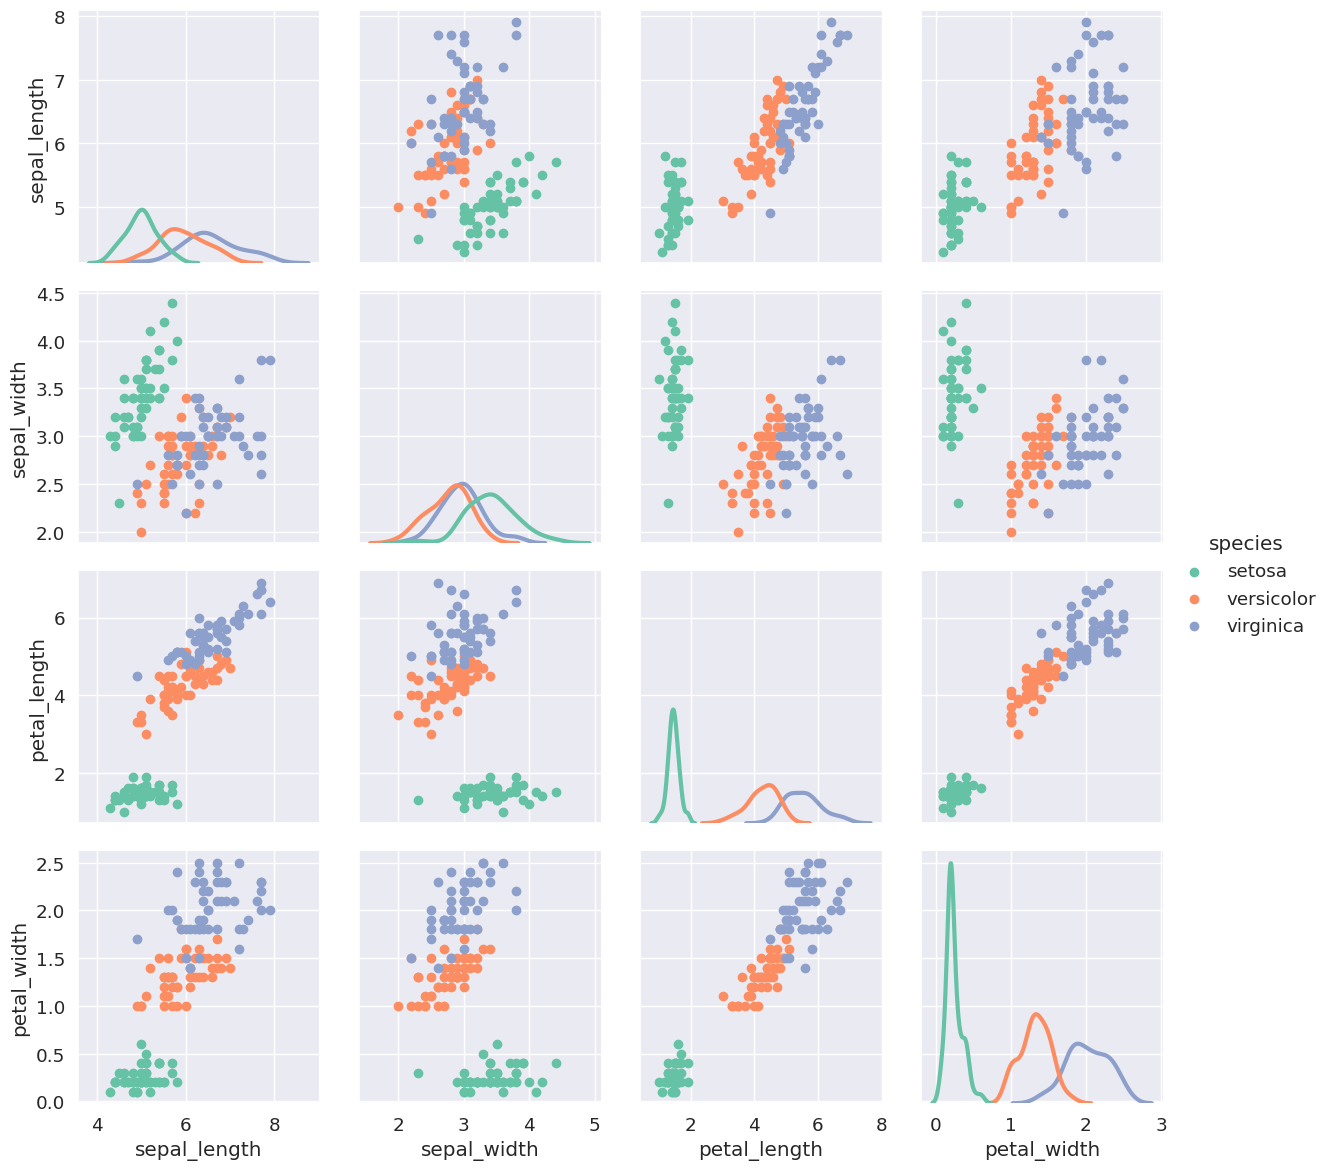

In [17]:
# g = sns.PairGrid(df, hue='species', size=3)
# g.map_offdiag(plt.scatter, cmap ="Blues_d")
# g.map_diag(sns.kdeplot, lw=3)
# plt.legend();

g = sns.PairGrid(df, hue='species', height=3) # поправка

g.map_offdiag(plt.scatter)
g.map_diag(sns.kdeplot, lw=3)

g.add_legend()

Для каждой характеристики цветка и каждого типа цветка проверьте с помощью <a href="https://thetahat.ru/files/bm-hf-2026-spr/stat/3/seminar3.html#Критерий-Шапиро-Уилка">критерия Шапиро-Уилка</a>, является ли соответствующая выборка нормальной с уровнем значимости $\alpha=0.05$. Всего нужно совешить 12 проверок (4 характеристики, 3 типа). Например, нужно проверить, является ли выборка `df[df['species'] == 'virginica']['sepal_length']` нормальной.

In [20]:
alpha = 0.05

features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
species = df['species'].unique()

for flower_type in species:
    print(f"Тип цветка: {flower_type}")

    for feature in features:
        sample = df[df['species'] == flower_type][feature]

        stat, p_value = sps.shapiro(sample)

        if p_value < alpha:
            result = "не нормальное распределение"
        else:
            result = "нормальное распределение"

        print(f"  {feature}: statistic = {stat:.4f}, p-value = {p_value:.4f} → {result}")

    print()

Тип цветка: setosa
  sepal_length: statistic = 0.9777, p-value = 0.4595 → нормальное распределение
  sepal_width: statistic = 0.9717, p-value = 0.2715 → нормальное распределение
  petal_length: statistic = 0.9550, p-value = 0.0548 → нормальное распределение
  petal_width: statistic = 0.7998, p-value = 0.0000 → не нормальное распределение

Тип цветка: versicolor
  sepal_length: statistic = 0.9778, p-value = 0.4647 → нормальное распределение
  sepal_width: statistic = 0.9741, p-value = 0.3380 → нормальное распределение
  petal_length: statistic = 0.9660, p-value = 0.1585 → нормальное распределение
  petal_width: statistic = 0.9476, p-value = 0.0273 → не нормальное распределение

Тип цветка: virginica
  sepal_length: statistic = 0.9712, p-value = 0.2583 → нормальное распределение
  sepal_width: statistic = 0.9674, p-value = 0.1809 → нормальное распределение
  petal_length: statistic = 0.9622, p-value = 0.1098 → нормальное распределение
  petal_width: statistic = 0.9598, p-value = 0.0870 →

Теперь для каждой характеристики для всех пар типов цветка проверьте с уровнем значимости $\alpha=0.05$, отличаются ли значения данной харатеристики для этих типов цветков (см. <a href="https://thetahat.ru/files/bm-hf-2026-spr/stat/3/seminar_3.pdf">презентацию с семинара</a>). Если для обеих выборок нормальность выше не отверглась, используйте <a href="https://thetahat.ru/files/bm-hf-2026-spr/stat/3/seminar3.html#T-критерий-Стьюдента-—-независимые-выборки">критерий Стьюдента</a>, иначе пользуйтесь <a href="https://thetahat.ru/files/bm-hf-2026-spr/stat/3/seminar3.html#Критерий-Смирнова">критерием Смирнова</a>. Например, нужно проверить, отличаются ли распределения выборкок `df[df['species'] == 'setosa']['sepal_length']` и `df[df['species'] == 'virginica']['sepal_length']`.

*Замечание*. Для применения критерия Стьюдента было бы правильнее предварительно проверить, что дисперсии выборок совпадает, но в данном задании это можно не делать.

In [28]:
from itertools import combinations
import pandas as pd

alpha = 0.05

features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
species = df['species'].unique()

normality = {}

for flower_type in species:
    for feature in features:
        sample = df[df['species'] == flower_type][feature]

        stat, p_value = sps.shapiro(sample)

        normality[(flower_type, feature)] = p_value >= alpha

results = []

for feature in features:
    for species_1, species_2 in combinations(species, 2):
        sample_1 = df[df['species'] == species_1][feature]
        sample_2 = df[df['species'] == species_2][feature]

        is_normal_1 = normality[(species_1, feature)]
        is_normal_2 = normality[(species_2, feature)]

        if is_normal_1 and is_normal_2:
            # t-критерий Стьюдента для независимых выборок
            stat, p_value = sps.ttest_ind(sample_1, sample_2)
            test_name = "t-критерий Стьюдента"
        else:
            # критерий Смирнова для двух независимых выборок
            stat, p_value = sps.ks_2samp(sample_1, sample_2)
            test_name = "критерий Смирнова"

        reject_h0 = p_value < alpha

        results.append({
            "feature": feature,
            "species_1": species_1,
            "species_2": species_2,
            "normal_1": is_normal_1,
            "normal_2": is_normal_2,
            "test": test_name,
            "statistic": stat,
            "p_value": p_value,
            "reject_h0": reject_h0,
            "conclusion": "отличаются" if reject_h0 else "нет оснований считать, что отличаются"
        })

comparison_results = pd.DataFrame(results)

comparison_results

,feature,species_1,species_2,normal_1,normal_2,test,statistic,p_value,reject_h0,conclusion
0,sepal_length,setosa,versicolor,True,True,t-критерий Стьюдента,-10.520986,8.985235e-18,True,отличаются
1,sepal_length,setosa,virginica,True,True,t-критерий Стьюдента,-15.386196,6.892546e-28,True,отличаются
2,sepal_length,versicolor,virginica,True,True,t-критерий Стьюдента,-5.629165,1.724856e-07,True,отличаются
3,sepal_width,setosa,versicolor,True,True,t-критерий Стьюдента,9.454976,1.845260e-15,True,отличаются
4,sepal_width,setosa,virginica,True,True,t-критерий Стьюдента,6.450349,4.246355e-09,True,отличаются
5,sepal_width,versicolor,virginica,True,True,t-критерий Стьюдента,-3.205761,1.819100e-03,True,отличаются
6,petal_length,setosa,versicolor,True,True,t-критерий Стьюдента,-39.492719,5.404911e-62,True,отличаются
7,petal_length,setosa,virginica,True,True,t-критерий Стьюдента,-49.986186,1.504801e-71,True,отличаются
8,petal_length,versicolor,virginica,True,True,t-критерий Стьюдента,-12.603779,3.178820e-22,True,отличаются
9,petal_width,setosa,versicolor,False,False,критерий Смирнова,1.000000,1.982331e-29,True,отличаются


**Вывод:** Видим, что все статистически отличаются, при том с большим запасом, на a = 0.001 есть первое не отличимое значение


__________________
### Задача 6

Сколько проверок статистических гипотез пришлось совершить в предыдущей задачи?

24, по 12 для проверки будет ли распределение нормальным и для проверки статистических отличий

Каким числом ограничена вероятность ошибки первого рода в каждой проверке?

a = 0.05, значит наща ошибка или p-value должно быть меньше нее

Такую ошибку мы могли совершить в каждой проверке. Вероятность совершения хотя бы одной ошибки первого рода среди всех проверок не превосходит произведения указанных вами чисел. Но нам хотелось бы, чтобы вероятность совершения хотя бы одной ошибки первого рода не превосходила $\alpha=0.05$. Можете ли вы предложить решение данной проблемы?

по идее нам нужно иметь суммарное a_sum = 0.05 =? 24 * a_new -> a_new = 0.05/24, по идее вероятность,что мы не ошиблись просто перемножается -> суммируется, и это будет с запасом


Реализуйте этот способ для предыдущей задачи

In [30]:
alpha = 0.05

features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
species = df['species'].unique()

m = 24
alpha_bonf = alpha / m

alpha_bonf



0.0020833333333333333

In [31]:
normality_results_bonf = []
normality_bonf = {}

for flower_type in species:
    for feature in features:
        sample = df[df['species'] == flower_type][feature]

        stat, p_value = sps.shapiro(sample)

        reject_h0 = p_value < alpha_bonf
        is_normal = not reject_h0

        normality_bonf[(flower_type, feature)] = is_normal

        normality_results_bonf.append({
            "species": flower_type,
            "feature": feature,
            "test": "критерий Шапиро-Уилка",
            "statistic": stat,
            "p_value": p_value,
            "alpha_bonf": alpha_bonf,
            "reject_h0": reject_h0,
            "conclusion": "нормальность отвергается" if reject_h0 else "нет оснований отвергнуть нормальность"
        })

normality_results_bonf = pd.DataFrame(normality_results_bonf)

normality_results_bonf

,species,feature,test,statistic,p_value,alpha_bonf,reject_h0,conclusion
0,setosa,sepal_length,критерий Шапиро-Уилка,0.977699,4.595131e-01,0.002083,False,нет оснований отвергнуть нормальность
1,setosa,sepal_width,критерий Шапиро-Уилка,0.971720,2.715264e-01,0.002083,False,нет оснований отвергнуть нормальность
2,setosa,petal_length,критерий Шапиро-Уилка,0.954977,5.481147e-02,0.002083,False,нет оснований отвергнуть нормальность
3,setosa,petal_width,критерий Шапиро-Уилка,0.799764,8.658573e-07,0.002083,True,нормальность отвергается
4,versicolor,sepal_length,критерий Шапиро-Уилка,0.977836,4.647370e-01,0.002083,False,нет оснований отвергнуть нормальность
5,versicolor,sepal_width,критерий Шапиро-Уилка,0.974133,3.379951e-01,0.002083,False,нет оснований отвергнуть нормальность
6,versicolor,petal_length,критерий Шапиро-Уилка,0.966004,1.584778e-01,0.002083,False,нет оснований отвергнуть нормальность
7,versicolor,petal_width,критерий Шапиро-Уилка,0.947626,2.727780e-02,0.002083,False,нет оснований отвергнуть нормальность
8,virginica,sepal_length,критерий Шапиро-Уилка,0.971179,2.583147e-01,0.002083,False,нет оснований отвергнуть нормальность
9,virginica,sepal_width,критерий Шапиро-Уилка,0.967391,1.808960e-01,0.002083,False,нет оснований отвергнуть нормальность


In [33]:
comparison_results_bonf = []

for feature in features:
    for species_1, species_2 in combinations(species, 2):
        sample_1 = df[df['species'] == species_1][feature]
        sample_2 = df[df['species'] == species_2][feature]

        is_normal_1 = normality_bonf[(species_1, feature)]
        is_normal_2 = normality_bonf[(species_2, feature)]

        if is_normal_1 and is_normal_2:
            stat, p_value = sps.ttest_ind(sample_1, sample_2)
            test_name = "t-критерий Стьюдента"
        else:
            stat, p_value = sps.ks_2samp(sample_1, sample_2)
            test_name = "критерий Смирнова"

        reject_h0 = p_value < alpha_bonf

        comparison_results_bonf.append({
            "feature": feature,
            "species_1": species_1,
            "species_2": species_2,
            "normal_1": is_normal_1,
            "normal_2": is_normal_2,
            "test": test_name,
            "statistic": stat,
            "p_value": p_value,
            "alpha_bonf": alpha_bonf,
            "reject_h0": reject_h0,
            "conclusion": "отличаются" if reject_h0 else "нет оснований считать, что отличаются"
        })

comparison_results_bonf = pd.DataFrame(comparison_results_bonf)

comparison_results_bonf

,feature,species_1,species_2,normal_1,normal_2,test,statistic,p_value,alpha_bonf,reject_h0,conclusion
0,sepal_length,setosa,versicolor,True,True,t-критерий Стьюдента,-10.520986,8.985235e-18,0.002083,True,отличаются
1,sepal_length,setosa,virginica,True,True,t-критерий Стьюдента,-15.386196,6.892546e-28,0.002083,True,отличаются
2,sepal_length,versicolor,virginica,True,True,t-критерий Стьюдента,-5.629165,1.724856e-07,0.002083,True,отличаются
3,sepal_width,setosa,versicolor,True,True,t-критерий Стьюдента,9.454976,1.845260e-15,0.002083,True,отличаются
4,sepal_width,setosa,virginica,True,True,t-критерий Стьюдента,6.450349,4.246355e-09,0.002083,True,отличаются
5,sepal_width,versicolor,virginica,True,True,t-критерий Стьюдента,-3.205761,1.819100e-03,0.002083,True,отличаются
6,petal_length,setosa,versicolor,True,True,t-критерий Стьюдента,-39.492719,5.404911e-62,0.002083,True,отличаются
7,petal_length,setosa,virginica,True,True,t-критерий Стьюдента,-49.986186,1.504801e-71,0.002083,True,отличаются
8,petal_length,versicolor,virginica,True,True,t-критерий Стьюдента,-12.603779,3.178820e-22,0.002083,True,отличаются
9,petal_width,setosa,versicolor,False,True,критерий Смирнова,1.000000,1.982331e-29,0.002083,True,отличаются


In [34]:
comparison_results_bonf[
    ["feature", "species_1", "species_2", "test", "p_value", "alpha_bonf", "conclusion"]
]

,feature,species_1,species_2,test,p_value,alpha_bonf,conclusion
0,sepal_length,setosa,versicolor,t-критерий Стьюдента,8.985235e-18,0.002083,отличаются
1,sepal_length,setosa,virginica,t-критерий Стьюдента,6.892546e-28,0.002083,отличаются
2,sepal_length,versicolor,virginica,t-критерий Стьюдента,1.724856e-07,0.002083,отличаются
3,sepal_width,setosa,versicolor,t-критерий Стьюдента,1.845260e-15,0.002083,отличаются
4,sepal_width,setosa,virginica,t-критерий Стьюдента,4.246355e-09,0.002083,отличаются
5,sepal_width,versicolor,virginica,t-критерий Стьюдента,1.819100e-03,0.002083,отличаются
6,petal_length,setosa,versicolor,t-критерий Стьюдента,5.404911e-62,0.002083,отличаются
7,petal_length,setosa,virginica,t-критерий Стьюдента,1.504801e-71,0.002083,отличаются
8,petal_length,versicolor,virginica,t-критерий Стьюдента,3.178820e-22,0.002083,отличаются
9,petal_width,setosa,versicolor,критерий Смирнова,1.982331e-29,0.002083,отличаются


**Вывод:** Прикольно, поделили цветы статистикой на группы, стоит заметить, что нам все равно нужен набор цветов, чтоб опредлелить кто это, заметим, что даже с малым альфа у нас только одна выборка распределена ненормально, все остальное сходится
осталось обучить классификатор чтоб это все делить......


---
© 2026 команда <a href="https://thetahat.ru/">ThetaHat</a> для Статистики ФБМФ и ФЭФМ